# Dissertation Experiments

**Student:** Renee Maria Mendonca

**Student Code:** 221040908

## Implementation

**Dependencies**

*   **LangChain** is used as framework to develop RAG systems.
*   **ChromaDB** is used as a vector database to store the embedded chunks.



In [ ]:
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install langchain_experimental
!pip install -qU "langchain-chroma>=0.1.2"
!pip install unstructured
!pip install chromadb
!pip install datasets
!pip install langchain-huggingface
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.3/390.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.54.5
    Uninstalling openai-1.54.5:
      Successfully uninstalled openai-1.54.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.2/411.2 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.24
    Uninstalling langchain-core-0.3.24:
      Successfully uninstalled langchain-core-0.3.24
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.

**Imports**

In [ ]:
import os

import langchain
from langchain import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain.document_loaders import UnstructuredHTMLLoader
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain.schema.runnable import RunnablePassthrough
from langchain.text_splitter import CharacterTextSplitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.text_splitter import TokenTextSplitter
from langchain.text_splitter import NLTKTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_chroma import Chroma
from langchain_community.document_loaders import UnstructuredHTMLLoader
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema import Document

from google.colab import userdata

from datasets import load_dataset

from tqdm import tqdm

import nltk
nltk.download('punkt_tab')

import time

import numpy as np
import matplotlib.pyplot as plt

import logging
logging.getLogger('langchain_text_splitters.base').setLevel(logging.ERROR)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Load OpenAI API**

In [ ]:
# load OpenAI API key
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

### General RAG Functions

**Chunking Functions**

This function returns a list of chunks based on a `text` and a chunking `strategy`.



In [ ]:
def get_chunks(text, strategy, **kwargs):
    max_chunk_length = kwargs.get('max_chunk_length', 256 * 4)

    match strategy:
        case 'simple':
            # alternative option to do simple chunking
            #splitter = CharacterTextSplitter(
                #separator="\n\n",
                #chunk_size=kwargs.get('chunk_size', 256 * 4),
                #chunk_overlap=kwargs.get('chunk_overlap', 26 * 4)
                #)
            #return splitter.split_text(text)
            chunks = []
            chunk_size=kwargs.get('chunk_size', 256 * 3)

            start = 0

            while start < len(text):
                end = start + chunk_size
                chunks.append(text[start:end])
                start += chunk_size - chunk_overlap
            return chunks
        case 'recursive':
            splitter = RecursiveCharacterTextSplitter(
                separators=["\n\n", "\n", " ", ""],
                chunk_size=kwargs.get('chunk_size', 256 * 3),
                chunk_overlap=kwargs.get('chunk_overlap', 26 * 3)
                )
            return splitter.split_text(text)
        case 'token':
            splitter = TokenTextSplitter(
                encoding_name="cl100k_base",
                chunk_size=kwargs.get('chunk_size', 256),
                chunk_overlap=kwargs.get('chunk_overlap', 26)
                )
            return splitter.split_text(text)
        case 'semantic-percentile':
            embedding_model = chunk_size=kwargs.get('embedding_model')

            splitter = SemanticChunker(
              embedding_model,
              breakpoint_threshold_type="percentile"
            )
            chunks = splitter.split_text(text)

            if max_chunk_length:
                token_splitter = TokenTextSplitter(
                    encoding_name="cl100k_base",
                    chunk_size=max_chunk_length,
                    chunk_overlap=kwargs.get('chunk_overlap', 0)
                )
                processed_chunks = []
                for chunk in chunks:
                    processed_chunks.extend(token_splitter.split_text(chunk))

                chunks = processed_chunks

            return chunks
        case 'semantic-sd':
            embedding_model = chunk_size=kwargs.get('embedding_model')

            splitter = SemanticChunker(
              embedding_model,
              breakpoint_threshold_type="standard_deviation"
            )
            chunks = splitter.split_text(text)

            if max_chunk_length:
                token_splitter = TokenTextSplitter(
                    encoding_name="cl100k_base",
                    chunk_size=max_chunk_length,
                    chunk_overlap=kwargs.get('chunk_overlap', 0)
                )
                processed_chunks = []
                for chunk in chunks:
                    processed_chunks.extend(token_splitter.split_text(chunk))

                chunks = processed_chunks

            return chunks
        case 'nltk':
            # NLTKTextSplitter works with tokens
            splitter = NLTKTextSplitter(
                chunk_size=kwargs.get('chunk_size', 256),
                chunk_overlap=kwargs.get('chunk_overlap', 26)
            )
            return splitter.split_text(text)
        case _:
            raise ValueError("Invalid strategy")

**Document Preparation**

This function takes the news dataset and returns a list of `Document` objects ready to be indexed.

In [ ]:
def get_documents(dataset, strategy='simple', stats=False, plot=False, early_stop=False, sleep=False, **kwargs):
    docs = []
    chunk_lengths = []
    batch_size = 60
    delay_per_batch = 120

    for i, news in enumerate(tqdm(dataset['train'], desc="Chunking")):
        for chunk in get_chunks(news['body'], strategy, **kwargs):
            doc = Document(
                page_content=chunk,
                metadata={
                    'title': news.get('title', 'No Title'),
                    'source': news.get('source', 'No Source'),
                    'published_at': news.get('published_at', 'Unknown Date')
                }
            )
            docs.append(doc)
            chunk_lengths.append(len(chunk))

        if sleep and (i + 1) % batch_size == 0:
            time.sleep(delay_per_batch)

        if early_stop and i == 50:
            break
    if stats:
        print(f"Chunk stats: Count: {len(chunk_lengths)} | Avg. length: {np.mean(chunk_lengths):.2f} | Min. length: {np.min(chunk_lengths)} | Max. length: {np.max(chunk_lengths)}")
    if plot:
        plt.figure(figsize=(8, 4))
        plt.boxplot(chunk_lengths, vert=False, patch_artist=True)
        plt.title('Boxplot of Chunk Lengths')
        plt.xlabel('Chunk Length')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.yticks([1], [strategy])
        plt.show()
    return docs

**Debugging Function**

This function outputs the prompt send to the LLM.

In [ ]:
from langchain_core.runnables import RunnableLambda

def print_final_prompt_fn(inputs):
    print("Generated Prompt:")
    if isinstance(inputs, list):
        for message in inputs:
            if isinstance(message, dict):
                print(f"{message.get('role', 'unknown')}: {message.get('content', '')}")
            else:
                print(message)
    else:
        print(inputs)
    return inputs

print_final_prompt = RunnableLambda(print_final_prompt_fn)

### RAG Implementation

This function returns the vector database, retriever, and RAG chain.

In [ ]:
def rag(documents, llm, prompt, semantic_retrieval=False, persist_directory="", load_from_disk=False, return_vector_store=False, **kwargs):
    vector_store = None
    #embedding_model = kwargs.get('embedding_model', embedding_model)

    if load_from_disk:
        collection_name = kwargs.get('collection_name', 'default')
        vector_store = Chroma(collection_name=collection_name, embedding_function=embedding_model, persist_directory=persist_directory)
    else:
        if semantic_retrieval:
            batch_size = 100
            delay_per_batch = 120
            for i in range(0, len(documents), batch_size):
                batch = documents[i:i + batch_size]
                print(f"Processing batch {i // batch_size + 1} with {len(batch)} documents.")

                if vector_store is None:
                    if persist_directory:
                        collection_name = kwargs.get('collection_name', 'default')
                        vector_store = Chroma.from_documents(batch, embedding_model, persist_directory=persist_directory, collection_name=collection_name)
                    else:
                        vector_store = Chroma.from_documents(batch, embedding_model)
                else:
                    vector_store.add_documents(batch)

                #print(f"Waiting for {delay_per_batch} seconds to respect the API call rate limit per minute (RPM).")
                time.sleep(delay_per_batch)
        else:
            if persist_directory:
                collection_name = kwargs.get('collection_name', 'default')
                vector_store = Chroma.from_documents(documents, embedding_model, persist_directory=persist_directory, collection_name=collection_name)
            else:
                vector_store = Chroma.from_documents(documents, embedding_model)

    retriever = vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": kwargs.get('k', 20)}
    )

    def rag_chain(query):
        retrieved_chunks = retriever.invoke(query)
        context_data = {"context": retrieved_chunks, "query": query}
        try:
            result = prompt.invoke(context_data)
            result = llm.invoke(result)
        except Exception as e:
            print(f"Error during execution: {e}")
            result = ""

        return result, retrieved_chunks

    #rag_chain = ({"context": retriever, "query": RunnablePassthrough()} | prompt | llm | RunnablePassthrough())
    #return vector_store, retriever, rag_chain
    if return_vector_store:
        return vector_store, retriever, rag_chain
    else:
        return rag_chain

### Evaluation Functions

**Evaluation Functions**

In [ ]:
def has_intersection(predicted, actual):
    predicted_words = set(predicted.lower().split())
    actual_words = set(actual.lower().split())
    return len(predicted_words.intersection(actual_words)) > 0

def calculate_metrics_acc(pred_list, gold_list):
    tp = sum(1 for pred, gold in zip(pred_list, gold_list) if has_intersection(pred, gold))
    fp = sum(1 for pred, gold in zip(pred_list, gold_list) if not has_intersection(pred, gold))
    fn = len(gold_list) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def calculate_metrics(predicted_evidence, golden_evidence):
    predicted_evidence = [item.replace(" ", "").replace("\n", "") for item in predicted_evidence]
    golden_evidence = [item.replace(" ", "").replace("\n", "") for item in golden_evidence]

    true_positives = 0
    false_positives = 0
    false_negatives = 0

    for golden_item in golden_evidence:
        found = any(golden_item in chunk for chunk in predicted_evidence)
        if found:
            true_positives += 1
        else:
            false_negatives += 1

    for predicted_item in predicted_evidence:
        if not any(predicted_item in golden_item for golden_item in golden_evidence):
            false_positives += 1

    precision = true_positives / (true_positives + false_positives) if true_positives + false_positives > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if true_positives + false_negatives > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return precision, recall, f1

def evaluate(rag_chain, dataset_qa, samples=None):
    pred_list = []
    gold_list = []
    all_predicted_evidence = []
    all_golden_evidence = []

    if samples != None:
        dataset = dataset_qa["train"].select(range(samples))
    else:
        dataset = dataset_qa["train"]

    for i, example in enumerate(tqdm(dataset, desc="Evaluation", unit="")):
        query = example["query"]
        ground_truth = example["answer"]
        evidence_golden_list = example["evidence_list"]

        result = None
        retrieved_chunks = None

        try:
          result, retrieved_chunks = rag_chain(query)
        except Exception as e:
          print(f"[[[[{query}]]]]")
          print(f"Exception type: {type(e).__name__}")
          print(f"Exception message: {str(e)}")
        prediction = result.content if result else "Insufficient Information"

        pred_list.append(prediction)
        gold_list.append(ground_truth)

        # print query
        print(f'\nQuestion: {query}')
        # print ground truth
        print(f'Ground Truth: {ground_truth}')
        # print prediction evaluation
        print(f'Result: {prediction}\tCheck: {"Correct" if prediction == ground_truth else "Incorrect"}')

        if (i + 1) % 1 == 0:
            golden_evidence = []
            predicted_evidence = []

            for evidence in evidence_golden_list:
                golden_evidence.append(evidence["fact"])

            for evidence in retrieved_chunks:
                predicted_evidence.append(evidence.page_content)

            all_predicted_evidence.extend(predicted_evidence)
            all_golden_evidence.extend(golden_evidence)

            #print(f"Retrieved Evidence: {predicted_evidence}")
            #print(f"Golden Evidence: {golden_evidence}")

            precision, recall, f1 = calculate_metrics(predicted_evidence, golden_evidence)
            print(f"Retrieval: \tPrecision:{precision:.2f}\tRecall: {recall:.2f}\tF1 Score: {f1:.2f}")

            overall_precision, overall_recall, overall_f1 = calculate_metrics(all_predicted_evidence, all_golden_evidence)
            print(f"Overall Retrieval:\tPrecision:{overall_precision:.2f}\tRecall: {overall_recall:.2f}\tF1 Score: {overall_f1:.2f}")

            accuracy, _, _ = calculate_metrics_acc(pred_list, gold_list)
            print(f"Overall Accuracy: {accuracy:.2f}\n")

        if samples != None and i >= samples:
            #evaluation_loop.close()
            break

**Load Datasets**

Load dataset from [yixuantt/MultiHopRAG](https://huggingface.co/datasets/yixuantt/MultiHopRAG)

In [ ]:
# load dataset (news articles)
dataset = load_dataset("yixuantt/MultiHopRAG", 'corpus')

# load test data (question-answer pairs)
dataset_qa = load_dataset("yixuantt/MultiHopRAG", 'MultiHopRAG')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

corpus.json:   0%|          | 0.00/6.79M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/609 [00:00<?, ? examples/s]

MultiHopRAG.json:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2556 [00:00<?, ? examples/s]

**General Experiment Setup**

Initialization of reusable objects for experiments.

In [ ]:
# initialize embedding model
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

# initialize generation model
llm_3_5_turbo = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
llm_4 = ChatOpenAI(model="gpt-4", temperature=0)
llm_4o_mini = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# chunking parameters (in number of characters)
chunk_size = 256 * 3
chunk_overlap = 26 * 3

# define path to save vector database
persist_directory = "./chroma_db"

if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

# prompt definition
prefix = "Below is a question followed by some context from different sources. Please answer the question based on the context. The answer to the question is a word or entity. If the provided information is insufficient to answer the question, respond 'Insufficient Information'. Answer directly without explanation."
prompt_template = f"{prefix}\n\nQuestion:{{query}}\n\nContext:\n\n{{context}}"
prompt = ChatPromptTemplate.from_template(prompt_template)

## Experiment A: Naive RAG

### Chunking Experiments

**Simple Splitting**

Chunking: 100%|██████████| 609/609 [00:00<00:00, 6267.93it/s]


Chunk stats: Count: 9430 | Avg. length: 740.48 | Min. length: 1 | Max. length: 768


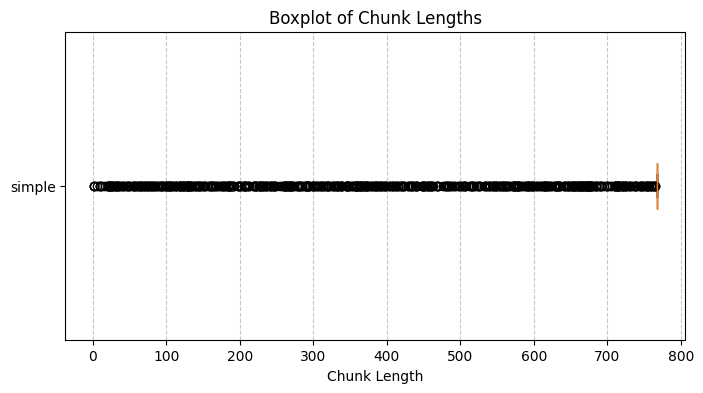

In [ ]:
documents = get_documents(dataset=dataset, strategy='simple', stats=True, plot=True)

Evaluation (100 samples)

#### GPT-3.5-turbo + Simple Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_simple_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<01:49,  1.11s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:13,  1.34/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.09	Recall: 0.80	F1 Score: 0.16
Overall Accuracy: 0.50



Evaluation:   3%|▎         | 3/100 [00:02<01:05,  1.48/s]

...

Overall Retrieval:	Precision:0.08	Recall: 0.73	F1 Score: 0.15
Overall Accuracy: 0.42



Evaluation:  99%|█████████▉| 99/100 [01:13<00:00,  1.08/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.73	F1 Score: 0.15
Overall Accuracy: 0.41



Evaluation: 100%|██████████| 100/100 [01:15<00:00,  1.33/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.72	F1 Score: 0.15
Overall Accuracy: 0.41



#### GPT-4o-mini + Simple Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_simple_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   3%|▎         | 1/30 [00:00<00:17,  1.64/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   7%|▋         | 2/30 [00:01<00:16,  1.68/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:  10%|█         | 3/30 [00:01<00:17,  1.51/s]

...


Question: Does the TechCrunch article suggest that Amazon's large language model (LLM) is not trained on kids' responses, while The Age article raises concerns about TikTok's pixel collecting data without consent?
Ground Truth: Yes
Result: Yes	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.06	Recall: 0.56	F1 Score: 0.11
Overall Accuracy: 0.47



Evaluation:  97%|█████████▋| 29/30 [00:18<00:00,  1.62/s]


Question: Did the report from Cnbc | World Business News Leader on "Nike's Latin America and Asia Pacific unit" or the article from Fortune on the "U.S. home sales price" both report a decrease in their respective financial figures?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.06	Recall: 0.56	F1 Score: 0.11
Overall Accuracy: 0.45



Evaluation: 100%|██████████| 30/30 [00:18<00:00,  1.60/s]


Question: Did the coverage of ski resorts by 'The Independent - Travel' change after their report on the 'Swiss slopes of Zermatt and pistes of Vail in Colorado' on October 13th, 2023, compared to their subsequent report on 'Tremblant Ski Resort' on October 25th, 2023?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.06	Recall: 0.58	F1 Score: 0.11
Overall Accuracy: 0.44



**Recursive Splitting**

Chunking: 100%|██████████| 609/609 [00:00<00:00, 910.16it/s]


Chunk stats: Count: 11037 | Avg. length: 581.72 | Min. length: 10 | Max. length: 768


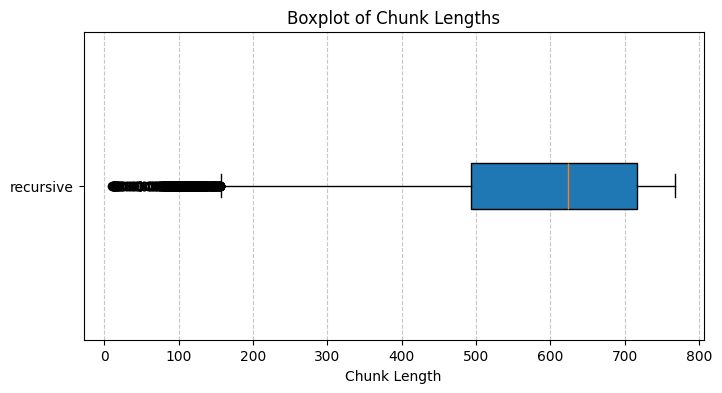

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', chunk_size=chunk_size, chunk_overlap=chunk_overlap, stats=True, plot=True)

Evaluation (100 samples)

#### GPT-3.5-turbo + Recursive Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:59,  1.67/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:03<03:15,  1.99s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 0.50



Evaluation:   3%|▎         | 3/100 [00:04<02:09,  1.33s/]

...

Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.36


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes.	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08


Evaluation:  99%|█████████▉| 99/100 [01:11<00:00,  1.36/s]

Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.35


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09


Evaluation: 100%|██████████| 100/100 [01:12<00:00,  1.37/s]

Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.35



#### GPT-4 + Recursive Chunking

In [ ]:
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<02:34,  1.56s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:03<02:33,  1.57s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:04<02:23,  1.48s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.64



Evaluation:  99%|█████████▉| 99/100 [04:01<00:02,  2.98s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.64



Evaluation: 100%|██████████| 100/100 [04:04<00:00,  2.44s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.63



#### GPT-4o-mini + Recursive Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:09,  1.41/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:31,  1.07/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:11,  1.37/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.59



Evaluation:  99%|█████████▉| 99/100 [01:38<00:00,  1.20/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [01:39<00:00,  1.01/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.59



**Token-based Splitting**

Chunking: 100%|██████████| 609/609 [00:01<00:00, 329.30it/s]


Chunk stats: Count: 6296 | Avg. length: 1105.67 | Min. length: 83 | Max. length: 1547


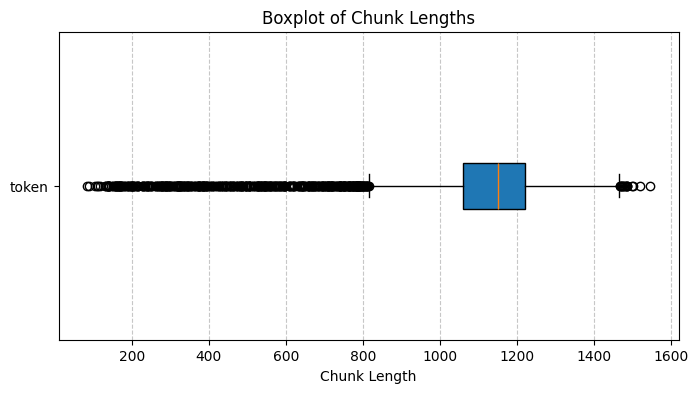

In [ ]:
documents = get_documents(dataset=dataset, strategy='token', stats=True, plot=True)

Evaluation (100 samples)

#### GPT-3.5-turbo + Token-based Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_token_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:26,  1.14/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:09,  1.41/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:04,  1.49/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.39



Evaluation:  99%|█████████▉| 99/100 [01:22<00:01,  1.18s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.38



Evaluation: 100%|██████████| 100/100 [01:23<00:00,  1.20/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.38



#### GPT-4 + Token-based Chunking

In [ ]:
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_token_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:02<04:35,  2.78s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:06<05:03,  3.10s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:07<03:57,  2.45s/]

...

Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.64



Evaluation:  99%|█████████▉| 99/100 [07:04<00:04,  4.63s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.64



Evaluation: 100%|██████████| 100/100 [07:08<00:00,  4.29s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.63



#### GPT-4o-mini + Token-based Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:31,  1.09/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:24,  1.16/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:25,  1.14/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.59



Evaluation:  99%|█████████▉| 99/100 [01:34<00:01,  1.02s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [01:35<00:00,  1.05/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.09	Recall: 0.79	F1 Score: 0.16
Overall Accuracy: 0.59



**Semantic Splitting (Percentile-based)**

Chunking: 100%|██████████| 609/609 [08:15<00:00,  1.23it/s]

Chunk stats: Count: 3622 | Avg. length: 1733.10 | Min. length: 1 | Max. length: 5663


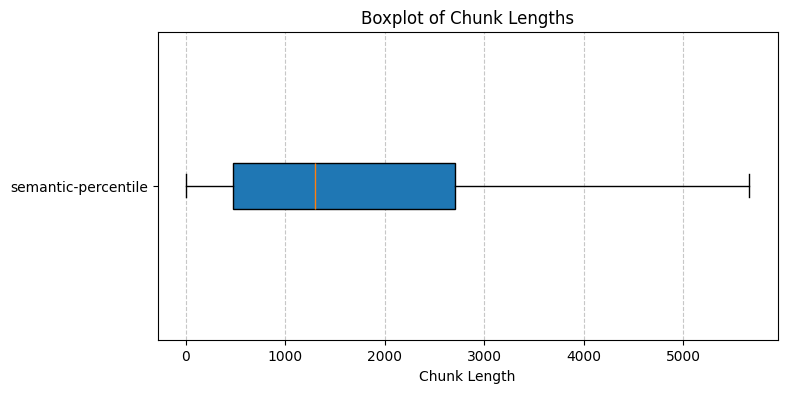

In [ ]:
documents = get_documents(dataset=dataset, strategy='semantic-percentile', embedding_model=embedding_model, stats=True, plot=True)

After setting a maximum chunk length

Chunking: 100%|██████████| 609/609 [09:52<00:00,  1.03it/s]

Chunk stats: Count: 7325 | Avg. length: 856.97 | Min. length: 1 | Max. length: 1532


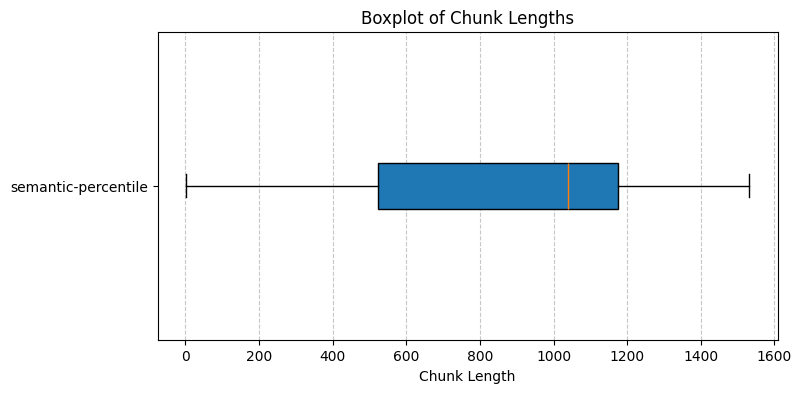

In [ ]:
documents = get_documents(dataset=dataset, strategy='semantic-percentile', embedding_model=embedding_model, stats=True, plot=True, max_chunk_length= 256)

Evaluation (100 samples)

#### GPT-3.5-turbo + Semantic (P) Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_semantic_p_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:13,  1.35/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:07,  1.46/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.09	Recall: 0.80	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:04,  1.51/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.38



Evaluation:  99%|█████████▉| 99/100 [01:15<00:00,  1.09/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: They both agree.	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.37



Evaluation: 100%|██████████| 100/100 [01:16<00:00,  1.31/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.37



#### GPT-4o-mini + Semantic (P) Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_semantic_p_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<01:39,  1.00s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:21,  1.21/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.09	Recall: 0.80	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:18,  1.23/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.57



Evaluation:  99%|█████████▉| 99/100 [01:32<00:00,  1.09/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.58



Evaluation: 100%|██████████| 100/100 [01:33<00:00,  1.07/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.09	Recall: 0.76	F1 Score: 0.15
Overall Accuracy: 0.57



**Semantic Splitting (Based on Standard Deviation)**

Chunking: 100%|██████████| 609/609 [08:12<00:00,  1.24it/s]

Chunk stats: Count: 1969 | Avg. length: 3189.23 | Min. length: 1 | Max. length: 5749


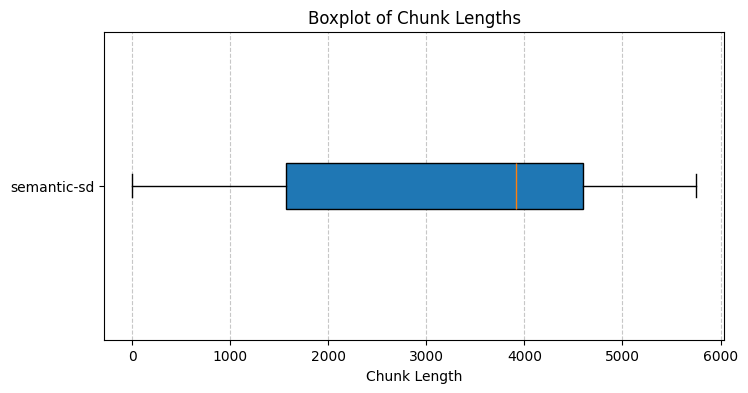

In [ ]:
documents = get_documents(dataset=dataset, strategy='semantic-sd', embedding_model= embedding_model, stats=True, plot=True)

After setting a maximum chunk length

Chunking: 100%|██████████| 609/609 [28:44<00:00,  2.83s/it]


Chunk stats: Count: 5993 | Avg. length: 1047.82 | Min. length: 1 | Max. length: 1541


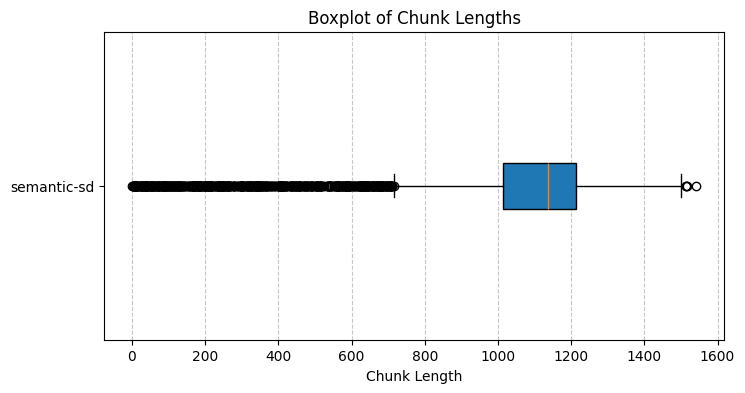

In [ ]:
documents = get_documents(dataset=dataset, strategy='semantic-sd', embedding_model= embedding_model, stats=True, plot=True, max_chunk_length= 256, sleep=True)

Evaluation (100 samples)

#### GPT-3.5-turbo + Semantic (SD) Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_semantic_sd_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:05,  1.50/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:05,  1.50/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<01:01,  1.58/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.38



Evaluation:  99%|█████████▉| 99/100 [01:20<00:00,  1.28/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.37



Evaluation: 100%|██████████| 100/100 [01:21<00:00,  1.23/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.37



#### GPT-4o-mini + Semantic (SD) Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, semantic_retrieval=True, persist_directory=persist_directory, collection_name="exp_semantic_sd_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:04<07:07,  4.32s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:05<03:52,  2.37s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:06<02:47,  1.73s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.55



Evaluation:  99%|█████████▉| 99/100 [01:44<00:01,  1.02s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.56



Evaluation: 100%|██████████| 100/100 [01:45<00:00,  1.06s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.55



**NLTK Splitting**

Chunking: 100%|██████████| 609/609 [00:01<00:00, 336.43it/s]


Chunk stats: Count: 30906 | Avg. length: 203.21 | Min. length: 2 | Max. length: 2726


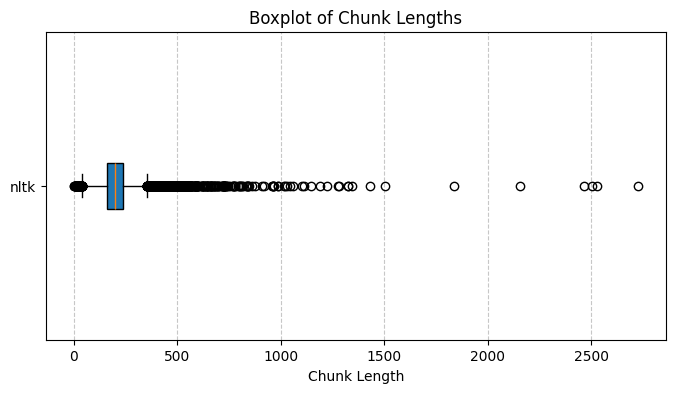

In [ ]:
documents = get_documents(dataset=dataset, strategy='nltk', stats=True, plot=True)

Evaluation (100 samples)

#### GPT-3.5-turbo + NLTK Chunking

In [ ]:
rag_chain = rag(documents, llm_3_5_turbo, prompt, persist_directory=persist_directory, collection_name="exp_nltk_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:55,  1.80/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.14	Recall: 1.00	F1 Score: 0.24
Overall Retrieval:	Precision:0.14	Recall: 1.00	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<00:56,  1.74/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.11	Recall: 1.00	F1 Score: 0.20
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:54,  1.80/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.07	Recall: 0.58	F1 Score: 0.12
Overall Accuracy: 0.37



Evaluation:  99%|█████████▉| 99/100 [01:02<00:00,  1.44/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.57	F1 Score: 0.12
Overall Accuracy: 0.36



Evaluation: 100%|██████████| 100/100 [01:02<00:00,  1.59/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.58	F1 Score: 0.12
Overall Accuracy: 0.36



#### GPT-4o-mini + NLTK Chunking

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_nltk_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:07,  1.47/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.14	Recall: 1.00	F1 Score: 0.24
Overall Retrieval:	Precision:0.14	Recall: 1.00	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:10,  1.40/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.11	Recall: 1.00	F1 Score: 0.20
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:20,  1.21/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.07	Recall: 0.58	F1 Score: 0.12
Overall Accuracy: 0.60



Evaluation:  99%|█████████▉| 99/100 [01:11<00:00,  1.50/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.57	F1 Score: 0.12
Overall Accuracy: 0.61



Evaluation: 100%|██████████| 100/100 [01:12<00:00,  1.38/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.07	Recall: 0.58	F1 Score: 0.12
Overall Accuracy: 0.60



*Note: The low recall is probably due to many of the evidence is in group of two or more sentences. NLTK splits based on sentences.*

### Embedding Model Experiments

**Load Embedding Models**

The following experiments use `sentence-transformers/sentence-t5-base` and `BAAI/bge-large-en-v1.5`.

In [ ]:
embedding_model_t5 = HuggingFaceEmbeddings(model_name="sentence-transformers/sentence-t5-base")

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

...

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2_Dense/config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

rust_model.ot:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [ ]:
embedding_model_bge = HuggingFaceEmbeddings(model_name="BAAI/bge-large-en-v1.5")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Chunking: 100%|██████████| 609/609 [00:00<00:00, 618.70it/s] 


Chunk stats: Count: 11037 | Avg. length: 581.72 | Min. length: 10 | Max. length: 768


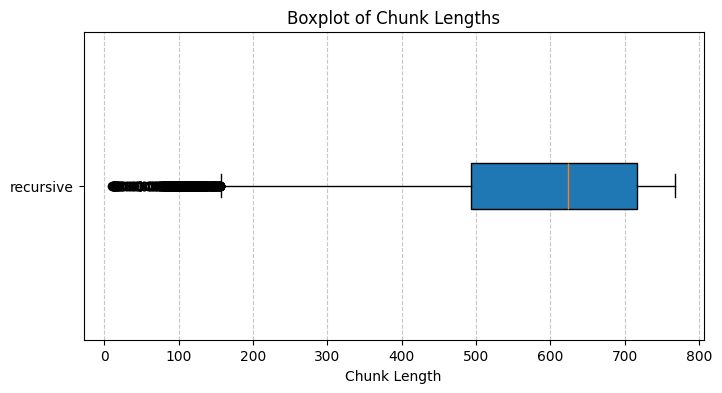

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', chunk_size=chunk_size, chunk_overlap=chunk_overlap, stats=True, plot=True)

#### GPT-4 + `sentence-t5-base`

In [ ]:
# set new embedding model
embedding_model = embedding_model_t5

# define new rag
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_recursive_t5_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<02:19,  1.41s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:02<01:42,  1.05s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:03<01:36,  1.01/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.60


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08


Evaluation:  99%|█████████▉| 99/100 [04:06<00:03,  3.09s/]

Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [04:09<00:00,  2.49s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.59



#### GPT-4 + `bge-large-en-v1.5`

In [ ]:
# set new embedding model
embedding_model = embedding_model_bge

# define new rag
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_recursive_bge_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:04<06:39,  4.04s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:04<03:31,  2.16s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.05	Recall: 0.40	F1 Score: 0.09
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:05<02:28,  1.53s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.65



Evaluation:  99%|█████████▉| 99/100 [03:59<00:03,  3.02s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.65



Evaluation: 100%|██████████| 100/100 [04:01<00:00,  2.41s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.64



#### GPT-4o-mini + `sentence-t5-base`

In [ ]:
# set new embedding model
embedding_model = embedding_model_t5

# define new rag
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_t5_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:43,  2.26/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:00<00:39,  2.51/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<01:07,  1.45/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.54



Evaluation:  99%|█████████▉| 99/100 [00:58<00:00,  1.52/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.55



Evaluation: 100%|██████████| 100/100 [00:59<00:00,  1.69/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.70	F1 Score: 0.14
Overall Accuracy: 0.54



#### GPT-4o-mini + `bge-large-en-v1.5`

In [ ]:
# set new embedding model
embedding_model = embedding_model_bge

# define new rag
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_bge_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:48,  2.04/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<00:49,  1.97/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.05	Recall: 0.40	F1 Score: 0.09
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:51,  1.88/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.54



Evaluation:  99%|█████████▉| 99/100 [01:10<00:01,  1.03s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.55



Evaluation: 100%|██████████| 100/100 [01:11<00:00,  1.40/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.54



#### GPT-4 + Token-based + `sentence-t5-base`

In [ ]:
documents = get_documents(dataset=dataset, strategy='token', stats=True)

Chunking: 100%|██████████| 609/609 [00:01<00:00, 428.02it/s]

Chunk stats: Count: 6296 | Avg. length: 1105.67 | Min. length: 83 | Max. length: 1547


In [ ]:
# set new embedding model
embedding_model = embedding_model_t5

# define new rag
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_token_t5_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<02:45,  1.67s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:02<02:05,  1.28s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:03<01:57,  1.21s/]

...

Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.59



Evaluation:  99%|█████████▉| 99/100 [02:29<00:02,  2.36s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.59



Evaluation: 100%|██████████| 100/100 [02:31<00:00,  1.51s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.58



#### GPT-4 + Token-based + `bge-large-en-v1.5`

In [ ]:
# set new embedding model
embedding_model = embedding_model_bge

# define new rag
rag_chain = rag(documents, llm_4, prompt, persist_directory=persist_directory, collection_name="exp_token_bge_db")

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<02:03,  1.25s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:02<02:19,  1.42s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.05	Recall: 0.40	F1 Score: 0.09
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:04<02:22,  1.47s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.57



Evaluation:  99%|█████████▉| 99/100 [02:23<00:01,  1.32s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.57



Evaluation: 100%|██████████| 100/100 [02:24<00:00,  1.45s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.56



#### GPT-4o-mini + Token-based + `sentence-t5-base`

In [ ]:
# set new embedding model
embedding_model = embedding_model_t5

# define new rag
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_t5_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:57,  1.72/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:08,  1.43/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:03<01:54,  1.18s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.55



Evaluation:  99%|█████████▉| 99/100 [01:18<00:00,  1.29/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.56



Evaluation: 100%|██████████| 100/100 [01:19<00:00,  1.26/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.55



#### GPT-4o-mini + Token-based + `bge-large-en-v1.5`

In [ ]:
# set new embedding model
embedding_model = embedding_model_bge

# define new rag
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_bge_db", load_from_disk=True)

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:56,  1.77/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:00,  1.61/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.05	Recall: 0.40	F1 Score: 0.09
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:56,  1.73/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.55



Evaluation:  99%|█████████▉| 99/100 [01:09<00:00,  1.22/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.56



Evaluation: 100%|██████████| 100/100 [01:10<00:00,  1.42/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.67	F1 Score: 0.14
Overall Accuracy: 0.55



### Top-K Experiments

In [ ]:
documents = get_documents(dataset=dataset, strategy='token', stats=True)

Chunking: 100%|██████████| 609/609 [00:02<00:00, 281.84it/s]

Chunk stats: Count: 6296 | Avg. length: 1105.67 | Min. length: 83 | Max. length: 1547


In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_db")

#### GPT-4o-mini + Token-based + K=15

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_db", load_from_disk=True, k=15)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:06,  1.48/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Retrieval:	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:18,  1.25/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.12	Recall: 1.00	F1 Score: 0.21
Overall Retrieval:	Precision:0.09	Recall: 0.60	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:11,  1.37/s]

...

Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.18
Overall Accuracy: 0.59


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11


Evaluation:  99%|█████████▉| 99/100 [01:27<00:00,  1.09/s]

Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.18
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [01:28<00:00,  1.13/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.06	Recall: 0.50	F1 Score: 0.11
Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.19
Overall Accuracy: 0.59



#### GPT-4o-mini + Token-based + K=10

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_db", load_from_disk=True, k=10)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:59,  1.66/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<00:58,  1.66/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.17	Recall: 1.00	F1 Score: 0.29
Overall Retrieval:	Precision:0.13	Recall: 0.60	F1 Score: 0.21
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:56,  1.71/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.67	F1 Score: 0.27
Overall Retrieval:	Precision:0.14	Recall: 0.64	F1 Score: 0.22
Overall Accuracy: 0.57



Evaluation:  99%|█████████▉| 99/100 [01:12<00:00,  1.50/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.14	Recall: 0.64	F1 Score: 0.22
Overall Accuracy: 0.58



Evaluation: 100%|██████████| 100/100 [01:18<00:00,  1.28/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.50	F1 Score: 0.15
Overall Retrieval:	Precision:0.14	Recall: 0.64	F1 Score: 0.23
Overall Accuracy: 0.57



#### GPT-4o-mini + Token-based + K=5

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_token_db", load_from_disk=True, k=5)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<01:04,  1.54/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<00:57,  1.69/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.29	Recall: 1.00	F1 Score: 0.44
Overall Retrieval:	Precision:0.17	Recall: 0.40	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:52,  1.84/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.21	Recall: 0.55	F1 Score: 0.31
Overall Accuracy: 0.55



Evaluation:  99%|█████████▉| 99/100 [01:12<00:00,  1.34/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.21	Recall: 0.55	F1 Score: 0.31
Overall Accuracy: 0.56



Evaluation: 100%|██████████| 100/100 [01:12<00:00,  1.38/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.50	F1 Score: 0.25
Overall Retrieval:	Precision:0.21	Recall: 0.55	F1 Score: 0.31
Overall Accuracy: 0.55



In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', stats=True)

Chunking: 100%|██████████| 609/609 [00:00<00:00, 1821.66it/s]

Chunk stats: Count: 11037 | Avg. length: 581.72 | Min. length: 10 | Max. length: 768


In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db")

#### GPT-4o-mini + Recursive + K=15

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db", load_from_disk=True, k=15)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:55,  1.80/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Retrieval:	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<00:50,  1.94/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.12	Recall: 1.00	F1 Score: 0.21
Overall Retrieval:	Precision:0.09	Recall: 0.60	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:02<01:45,  1.09s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.12	Recall: 0.67	F1 Score: 0.20
Overall Retrieval:	Precision:0.10	Recall: 0.71	F1 Score: 0.18
Overall Accuracy: 0.56



Evaluation:  99%|█████████▉| 99/100 [01:15<00:00,  1.05/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Retrieval:	Precision:0.10	Recall: 0.71	F1 Score: 0.18
Overall Accuracy: 0.57



Evaluation: 100%|██████████| 100/100 [01:16<00:00,  1.31/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.06	Recall: 0.50	F1 Score: 0.11
Overall Retrieval:	Precision:0.10	Recall: 0.71	F1 Score: 0.18
Overall Accuracy: 0.56



#### GPT-4o-mini + Recursive + K=10

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db", load_from_disk=True, k=10)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:44,  2.23/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:01<01:00,  1.63/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.17	Recall: 1.00	F1 Score: 0.29
Overall Retrieval:	Precision:0.13	Recall: 0.60	F1 Score: 0.21
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:54,  1.78/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.13	Recall: 0.62	F1 Score: 0.22
Overall Accuracy: 0.53



Evaluation:  99%|█████████▉| 99/100 [02:29<00:00,  1.62/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.13	Recall: 0.61	F1 Score: 0.22
Overall Accuracy: 0.54



Evaluation: 100%|██████████| 100/100 [02:30<00:00,  1.50s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.50	F1 Score: 0.15
Overall Retrieval:	Precision:0.13	Recall: 0.61	F1 Score: 0.22
Overall Accuracy: 0.53



#### GPT-4o-mini + Recursive + K=5

In [ ]:
rag_chain = rag(documents, llm_4o_mini, prompt, persist_directory=persist_directory, collection_name="exp_recursive_db", load_from_disk=True, k=5)
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:00<00:54,  1.83/s]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:00<00:44,  2.20/s]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.29	Recall: 1.00	F1 Score: 0.44
Overall Retrieval:	Precision:0.23	Recall: 0.60	F1 Score: 0.33
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:01<00:47,  2.04/s]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.20	Recall: 0.49	F1 Score: 0.28
Overall Accuracy: 0.53



Evaluation:  99%|█████████▉| 99/100 [01:08<00:00,  1.70/s]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.20	Recall: 0.49	F1 Score: 0.28
Overall Accuracy: 0.54



Evaluation: 100%|██████████| 100/100 [01:09<00:00,  1.45/s]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.50	F1 Score: 0.25
Overall Retrieval:	Precision:0.20	Recall: 0.49	F1 Score: 0.28
Overall Accuracy: 0.53



## Experiment B: Advanced RAG

### LLM Re-ranking Experiments

Load the vector database

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', chunk_size=chunk_size, chunk_overlap=chunk_overlap)

vector_store = Chroma.from_documents(documents, embedding_model)

Chunking: 100%|██████████| 609/609 [00:00<00:00, 1025.75it/s]


In [ ]:
# set LLM reranker
llm_reranker = llm_4o_mini


# set top K
top_n = 5

Define the ranking function

In [ ]:
from pydantic import BaseModel, Field
from typing import List

class RatingScore(BaseModel):
    relevance_score: float = Field(..., description="The relevance score of a document to a query.")

def rerank_documents(query: str, docs: List[Document], top_n: int = 4) -> List[Document]:
    prompt_template = PromptTemplate(
        input_variables=["query", "doc"],
        template="""On a scale of 1-10, rate the relevance of the following document to the query. Consider the specific context and intent of the query, not just keyword matches.
        Query: {query}
        Document: {doc}
        Relevance Score:"""
    )

    llm = ChatOpenAI(temperature=0, model_name="gpt-4o-mini", max_tokens=4000)
    llm_chain = prompt_template | llm.with_structured_output(RatingScore)

    scored_docs = []
    for doc in docs:
        input_data = {"query": query, "doc": doc.page_content}
        score = llm_chain.invoke(input_data).relevance_score
        try:
            score = float(score)
        except ValueError:
            score = 0
        scored_docs.append((doc, score))

    reranked_docs = sorted(scored_docs, key=lambda x: x[1], reverse=True)
    return [doc for doc, _ in reranked_docs[:top_n]]

Define the custom re-ranking retriever

In [ ]:
from langchain.schema.retriever import BaseRetriever
from langchain.chains import RetrievalQA
from typing import Any
# Create a custom retriever class
class CustomRetriever(BaseRetriever, BaseModel):

    vectorstore: Any = Field(description="Vector store for initial retrieval")
    top_n: int = 5

    class Config:
        arbitrary_types_allowed = True

    def get_relevant_documents(self, query: str, num_docs=5) -> List[Document]:
        initial_docs = self.vectorstore.similarity_search(query, k=20)
        return rerank_documents(query, initial_docs, top_n=top_n)



custom_retriever = CustomRetriever(vectorstore=vector_store)

<ipython-input-14-5351bf19cacf>:5: DeprecationWarning: Retrievers must implement abstract `_get_relevant_documents` method instead of `get_relevant_documents`
  class CustomRetriever(BaseRetriever, BaseModel):


Define RAG chain

In [ ]:
def rag_chain(query):
    retrieved_chunks = custom_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_reranker.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

#### GPT-4o-mini + Recursive + LLM Re-ranking + K=5

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:09<15:38,  9.48s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:18<15:18,  9.37s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.29	Recall: 1.00	F1 Score: 0.44
Overall Retrieval:	Precision:0.17	Recall: 0.40	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:35<20:44, 12.83s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.21	Recall: 0.55	F1 Score: 0.31
Overall Accuracy: 0.60



Evaluation:  99%|█████████▉| 99/100 [19:34<00:12, 12.51s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.21	Recall: 0.54	F1 Score: 0.30
Overall Accuracy: 0.61



Evaluation: 100%|██████████| 100/100 [19:45<00:00, 11.86s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.50	F1 Score: 0.25
Overall Retrieval:	Precision:0.21	Recall: 0.54	F1 Score: 0.30
Overall Accuracy: 0.60



#### GPT-4o-mini + Recursive + LLM Re-ranking + K=10

In [ ]:
# set top K
top_n = 10

custom_retriever = CustomRetriever(vectorstore=vector_store, top_n=top_n)

def rag_chain(query):
    retrieved_chunks = custom_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_reranker.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:20<34:30, 20.91s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:32<25:07, 15.39s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.17	Recall: 1.00	F1 Score: 0.29
Overall Retrieval:	Precision:0.13	Recall: 0.60	F1 Score: 0.21
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:42<20:50, 12.90s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.67	F1 Score: 0.27
Overall Retrieval:	Precision:0.14	Recall: 0.69	F1 Score: 0.24
Overall Accuracy: 0.62



Evaluation:  99%|█████████▉| 99/100 [19:01<00:10, 10.97s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.14	Recall: 0.68	F1 Score: 0.24
Overall Accuracy: 0.63



Evaluation: 100%|██████████| 100/100 [19:13<00:00, 11.53s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.50	F1 Score: 0.15
Overall Retrieval:	Precision:0.14	Recall: 0.68	F1 Score: 0.24
Overall Accuracy: 0.62



#### GPT-4o-mini + Recursive + LLM Re-ranking + K=15

In [ ]:
# set top K
top_n = 15

custom_retriever = CustomRetriever(vectorstore=vector_store, top_n=top_n)

def rag_chain(query):
    retrieved_chunks = custom_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_reranker.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:14<23:52, 14.47s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Retrieval:	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:32<26:36, 16.29s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.12	Recall: 1.00	F1 Score: 0.21
Overall Retrieval:	Precision:0.09	Recall: 0.60	F1 Score: 0.16
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:49<27:17, 16.88s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.12	Recall: 0.67	F1 Score: 0.20
Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.18
Overall Accuracy: 0.59



Evaluation:  99%|█████████▉| 99/100 [24:37<00:14, 14.70s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.06	Recall: 0.33	F1 Score: 0.11
Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.18
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [24:53<00:00, 14.94s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.06	Recall: 0.50	F1 Score: 0.11
Overall Retrieval:	Precision:0.11	Recall: 0.72	F1 Score: 0.18
Overall Accuracy: 0.59



#### GPT-4o-mini + Recursive + LLM Re-ranking + K=20

In [ ]:
# set top K
top_n = 20

custom_retriever = CustomRetriever(vectorstore=vector_store, top_n=top_n)

def rag_chain(query):
    retrieved_chunks = custom_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_reranker.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:13<22:00, 13.34s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:26<21:39, 13.26s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:44<24:53, 15.40s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.67	F1 Score: 0.16
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.57



Evaluation:  99%|█████████▉| 99/100 [28:30<00:20, 20.41s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.58



Evaluation: 100%|██████████| 100/100 [28:47<00:00, 17.27s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.57



### Cross Encoder Re-ranking Experiments

Definition the Cross Encoder class


In [ ]:
from langchain.schema.retriever import BaseRetriever  # Corrected import path
from pydantic import BaseModel, Field
from typing import Any, List
from langchain.schema import Document  # Ensure Document is imported
from langchain.chains import RetrievalQA
from langchain.chat_models import ChatOpenAI

In [ ]:
from sentence_transformers import CrossEncoder  # Import CrossEncoder

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

class CrossEncoderRetriever(BaseRetriever, BaseModel):
    vector_store: Any = Field(description="Vector store for initial retrieval")
    cross_encoder: Any = Field(description="Cross-encoder model for reranking")
    k: int = Field(default=5, description="Number of documents to retrieve initially")
    rerank_top_k: int = Field(default=3, description="Number of documents to return after reranking")

    class Config:
        arbitrary_types_allowed = True

    def get_relevant_documents(self, query: str) -> List[Document]:
        # Initial retrieval
        initial_docs = self.vector_store.similarity_search(query, k=self.k)

        # Prepare pairs for cross-encoder
        pairs = [[query, doc.metadata.get('title') + " " + doc.page_content] for doc in initial_docs]

        # Get cross-encoder scores
        scores = self.cross_encoder.predict(pairs)

        # Sort documents by score
        scored_docs = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)

        # Return top reranked documents
        return [doc for doc, _ in scored_docs[:self.rerank_top_k]]

    async def aget_relevant_documents(self, query: str) -> List[Document]:
        raise NotImplementedError("Async retrieval not implemented")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

<ipython-input-12-5f1b6ca7d738>:5: DeprecationWarning: Retrievers must implement abstract `_get_relevant_documents` method instead of `get_relevant_documents`
  class CrossEncoderRetriever(BaseRetriever, BaseModel):
<ipython-input-12-5f1b6ca7d738>:5: DeprecationWarning: Retrievers must implement abstract `_aget_relevant_documents` method instead of `aget_relevant_documents`
  class CrossEncoderRetriever(BaseRetriever, BaseModel):


Loading the vector store for the custom retriever

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', chunk_size=chunk_size, chunk_overlap=chunk_overlap)

vector_store = Chroma.from_documents(documents, embedding_model)

Chunking: 100%|██████████| 609/609 [00:00<00:00, 1008.99it/s]


#### GPT-4o-mini + Recursive + Cross Encoder Re-ranking + Top 5 @ K=20

In [ ]:
cross_encoder_retriever = CrossEncoderRetriever(
    vector_store=vector_store,
    cross_encoder=cross_encoder,
    k=20,
    rerank_top_k=5
)

Definition of the custom RAG chain

In [ ]:
def rag_chain(query):
    retrieved_chunks = cross_encoder_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_4.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:02<04:36,  2.79s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:04<03:02,  1.86s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.29	Recall: 1.00	F1 Score: 0.44
Overall Retrieval:	Precision:0.17	Recall: 0.40	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:07<03:53,  2.41s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.20	Recall: 0.51	F1 Score: 0.29
Overall Accuracy: 0.60



Evaluation:  99%|█████████▉| 99/100 [02:24<00:02,  2.30s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.20	Recall: 0.50	F1 Score: 0.29
Overall Accuracy: 0.60



Evaluation: 100%|██████████| 100/100 [02:25<00:00,  1.46s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.50	F1 Score: 0.25
Overall Retrieval:	Precision:0.20	Recall: 0.50	F1 Score: 0.29
Overall Accuracy: 0.59



#### GPT-4o-mini + Recursive + Cross Encoder Re-ranking + Top 5 @ K=40

In [ ]:
cross_encoder_retriever = CrossEncoderRetriever(
    vector_store=vector_store,
    cross_encoder=cross_encoder,
    k=40,
    rerank_top_k=5
)

def rag_chain(query):
    retrieved_chunks = cross_encoder_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_4.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:01<02:00,  1.22s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:02<02:11,  1.34s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.29	Recall: 1.00	F1 Score: 0.44
Overall Retrieval:	Precision:0.17	Recall: 0.40	F1 Score: 0.24
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:03<02:09,  1.34s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.17	Recall: 0.33	F1 Score: 0.22
Overall Retrieval:	Precision:0.20	Recall: 0.52	F1 Score: 0.29
Overall Accuracy: 0.60



Evaluation:  99%|█████████▉| 99/100 [02:28<00:01,  1.73s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Both articles agree that Sportsbooks adjust their practices based on certain conditions.	Check: Incorrect
Retrieval: 	Precision:0.29	Recall: 0.67	F1 Score: 0.40
Overall Retrieval:	Precision:0.21	Recall: 0.52	F1 Score: 0.30
Overall Accuracy: 0.61



Evaluation: 100%|██████████| 100/100 [02:29<00:00,  1.49s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.50	F1 Score: 0.25
Overall Retrieval:	Precision:0.21	Recall: 0.53	F1 Score: 0.30
Overall Accuracy: 0.60



#### GPT-4o-mini + Recursive + Cross Encoder Re-ranking + Top 10 @ K=60

In [ ]:
cross_encoder_retriever = CrossEncoderRetriever(
    vector_store=vector_store,
    cross_encoder=cross_encoder,
    k=60,
    rerank_top_k=10
)

def rag_chain(query):
    retrieved_chunks = cross_encoder_retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_4.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:02<03:37,  2.20s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Retrieval:	Precision:0.00	Recall: 0.00	F1 Score: 0.00
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:04<03:13,  1.97s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.17	Recall: 1.00	F1 Score: 0.29
Overall Retrieval:	Precision:0.09	Recall: 0.40	F1 Score: 0.15
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:05<03:02,  1.88s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.09	Recall: 0.33	F1 Score: 0.14
Overall Retrieval:	Precision:0.13	Recall: 0.60	F1 Score: 0.21
Overall Accuracy: 0.61



Evaluation:  99%|█████████▉| 99/100 [02:46<00:01,  1.68s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.17	Recall: 0.67	F1 Score: 0.27
Overall Retrieval:	Precision:0.13	Recall: 0.60	F1 Score: 0.21
Overall Accuracy: 0.61



Evaluation: 100%|██████████| 100/100 [02:48<00:00,  1.68s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Insufficient Information	Check: Incorrect
Retrieval: 	Precision:0.09	Recall: 0.50	F1 Score: 0.15
Overall Retrieval:	Precision:0.13	Recall: 0.61	F1 Score: 0.21
Overall Accuracy: 0.60



### Multi-Query Experiments

#### GPT-4 + Recursive + Multi-Query

Setting up the vector store for the custom multi-query retriever

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', stats=True)
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = Chroma.from_documents(documents, embedding_model)

Chunking: 100%|██████████| 609/609 [00:00<00:00, 1138.12it/s]


Chunk stats: Count: 11037 | Avg. length: 581.72 | Min. length: 10 | Max. length: 768


In [ ]:
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_core.output_parsers import BaseOutputParser
from typing import List

class LineListOutputParser(BaseOutputParser[List[str]]):

    def parse(self, text: str) -> List[str]:
        lines = text.strip().split("\n")
        return list(filter(None, lines))

output_parser = LineListOutputParser()

# definition of the multi-query prompt
multi_query_prompt = PromptTemplate(
    input_variables=["question"],
    template="""You are an AI language model assistant. Your task is to generate twenty
    different questions that help to solve the given user question to retrieve relevant documents from a vector
    database. Focus on the names that appear in the question such as Sources, personal names, and year.
    Provide these alternative questions separated by newlines.
    Original question: {question}""",
)

# definition of the RAG chain
llm_chain = multi_query_prompt | llm_4o_mini | output_parser

retriever = MultiQueryRetriever(
    retriever=vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 20}
    ),
    llm_chain=llm_chain, parser_key="lines"
)

Example of multiquery retrieval (single question)

In [ ]:
question = "Does the TechCrunch article suggest that Apple imposes restrictions on browser selection on iPhones, while The Verge article claims that Apple enforces uniform terms through its store and payment system, and does the Engadget article focus on Apple's hardware updates rather than its software policies?"
retrieved_documents = retriever.invoke(question)
print(f'Documents Retrieved: {len(retrieved_documents)}')

Documents Retrieved: 123


In [ ]:
retrieved_documents

[Document(metadata={'published_at': '2023-10-31 02:30:32.000000000Z', 'source': 'TechCrunch', 'title': '5 things we learned so far about the Google antitrust case'}, page_content='Google agreed not to promote Chrome to Safari users\n\nAs part of its search deal with Apple, Google agreed not to promote Chrome to Safari users, reports Bloomberg. Google would have been able to do this with banners, pop-ups and other annoying means in other Google apps.\n\nThe agreement also meant that Apple never switched to a Google competitor or allowed users to choose their browser when setting up their iPhones.\n\nGoogle tried to be preinstalled on iPhones\n\nPichai admitted to attempting to get Tim Cook to preinstall Google on every iOS device back in 2018, according to The Verge. He hoped to make Google and Apple’s services so connected as to be inseparable.'),
 Document(metadata={'published_at': '2023-09-26 17:01:22.000000000Z', 'source': 'The Verge', 'title': 'Apple defends Google Search deal in c

Definition of the custom multi-query RAG chain

In [ ]:
def rag_chain(query):
    retrieved_chunks = retriever.invoke(query)
    context_data = {"context": retrieved_chunks, "query": query}
    try:
        result = prompt.invoke(context_data)
        result = llm_4o_mini.invoke(result)
    except Exception as e:
        print(f"Error during execution: {e}")
        result = ""

    return result, retrieved_chunks

In [ ]:
evaluate(rag_chain, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:20<33:05, 20.06s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.67	F1 Score: 0.09
Overall Retrieval:	Precision:0.05	Recall: 0.67	F1 Score: 0.09
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:35<28:37, 17.53s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.02	Recall: 1.00	F1 Score: 0.03
Overall Retrieval:	Precision:0.03	Recall: 0.80	F1 Score: 0.05
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [00:54<29:21, 18.16s/]

...

Overall Retrieval:	Precision:0.02	Recall: 0.98	F1 Score: 0.05
Overall Accuracy: 0.58


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.03	Recall: 0.67	F1 Score: 0.06


Evaluation:  99%|█████████▉| 99/100 [33:17<00:18, 18.36s/]

Overall Retrieval:	Precision:0.02	Recall: 0.98	F1 Score: 0.05
Overall Accuracy: 0.59


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.02	Recall: 0.50	F1 Score: 0.05


Evaluation: 100%|██████████| 100/100 [33:39<00:00, 20.20s/]

Overall Retrieval:	Precision:0.02	Recall: 0.98	F1 Score: 0.05
Overall Accuracy: 0.58



## Experiment C: Collaborative Multi-Agent RAG

### Implementation

**Dependencies**

In [ ]:
!pip install langchain langgraph openai
!pip install langchain-community
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install langchain_experimental
!pip install -qU "langchain-chroma>=0.1.2"
!pip install chromadb
!pip install datasets
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.1 MB/s eta 0:00:00


**Imports**

In [ ]:
import os

import langchain
from langchain import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain.schema.runnable import RunnablePassthrough
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema import Document
from langchain.schema import HumanMessage
from langchain.schema import SystemMessage
from langgraph.graph import StateGraph, END
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain.llms import OpenAI

from google.colab import userdata

from datasets import load_dataset

from tqdm import tqdm

import nltk
nltk.download('punkt_tab')

import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata

from typing import Dict, TypedDict, Optional
import random
import time

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Each agent retrieves from the vector database

In [ ]:
def naive_rag(documents, llm, prompt, semantic_retrieval=False, persist_directory="", load_from_disk=False, **kwargs):
    vector_store = None

    if load_from_disk:
        collection_name = kwargs.get('collection_name', 'default')
        vector_store = Chroma(collection_name=collection_name, embedding_function=embedding_model, persist_directory=persist_directory)
    else:
        if semantic_retrieval:
            batch_size = 100
            delay_per_batch = 120
            for i in range(0, len(documents), batch_size):
                batch = documents[i:i + batch_size]
                print(f"Processing batch {i // batch_size + 1} with {len(batch)} documents.")

                if vector_store is None:
                    if persist_directory:
                        collection_name = kwargs.get('collection_name', 'default')
                        vector_store = Chroma.from_documents(batch, embedding_model, persist_directory=persist_directory, collection_name=collection_name)
                    else:
                        vector_store = Chroma.from_documents(batch, embedding_model)
                else:
                    vector_store.add_documents(batch)

                #print(f"Waiting for {delay_per_batch} seconds to respect the API call rate limit per minute (RPM).")
                time.sleep(delay_per_batch)
        else:
            if persist_directory:
                collection_name = kwargs.get('collection_name', 'default')
                vector_store = Chroma.from_documents(documents, embedding_model, persist_directory=persist_directory, collection_name=collection_name)
            else:
                vector_store = Chroma.from_documents(documents, embedding_model)

    retriever = vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={"k": kwargs.get('k', 20)}
    )

    rag_chain = ({"context": retriever, "query": RunnablePassthrough()} | prompt)

    return vector_store, retriever, rag_chain

In [ ]:
# load OpenAI API key
openai_api_key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')


# define path to save vector database
persist_directory = "./chroma_db"

if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

# prompt definition
prefix = "Below is a question followed by some context from different sources. Please answer the question based on the context. The answer to the question is a word or entity. If the provided information is insufficient to answer the question, respond 'Insufficient Information'. Answer directly without explanation."
prompt_template = f"{prefix}\n\nQuestion:{{query}}\n\nContext:\n\n{{context}}"
prompt = ChatPromptTemplate.from_template(prompt_template)

# initialize embedding model
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

model_name = "gpt-4o-mini"

# LLM agents
llm = ChatOpenAI(model=model_name, temperature=0)

# LLM that generates the answer
llm_generator = ChatOpenAI(model=model_name, temperature=0)

# LLM that classifies answers
llm_classifier = ChatOpenAI(model=model_name, temperature=0)

# agent's names
classes = ["A", "B"]

prefix_start_colab='You are tasked with answering: "{}". Reason step by step, connecting multiple sources to identify the correct answer. The conversation so far: \n{}\n. Use this evidence: "{}" to build your argument, linking facts logically to support "{}". Provide your reasoning in one concise line.'

In [ ]:
documents = get_documents(dataset=dataset, strategy='recursive', stats=True)
_, retriever, rag_chain= naive_rag(documents, llm_generator, prompt)

Chunking: 100%|██████████| 609/609 [00:01<00:00, 434.33it/s]


Chunk stats: Count: 11037 | Avg. length: 581.72 | Min. length: 10 | Max. length: 768


Definition of the chain's state and workflow

In [ ]:
class GraphState(TypedDict):
    classification: Optional[str] = None
    history: Optional[str] = None
    current_response: Optional[str] = None
    count: Optional[int]=None
    results: Optional[str]=None
    greeting: Optional[str]=None
    query: Optional[str] = None

workflow = StateGraph(GraphState)

def classify(question):
    return (llm_classifier.invoke("classify the sentiment of input as {} or {}. Output just the class. Input:{}".format('_'.join(classes[0].split(' ')),'_'.join(classes[1].split(' ')),question))).content.strip()

def classify_input_node(state):
    question = state.get('current_response')
    classification = classify(question)
    return {"classification": classification}

def handle_greeting_node(state):
    return {"greeting": "Hello! Today we will witness the fight between A vs B"}

def handle_pro(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    query = state.get('query', '').strip()
    similar_chunks = retriever.get_relevant_documents(query)
    evidences = []
    for chunk in similar_chunks:
        title = chunk.metadata.get('title', 'Unknown')
        source = chunk.metadata.get('source', 'Unknown')
        published_at = chunk.metadata.get('published_at', 'Unknown')

        evidence = f"{chunk.page_content}\n"
        evidences.append(evidence)

    formatted_evidence = "\n".join(evidences)

    if summary=='Nothing':
        prompt = prefix_start_colab.format(query,summary,formatted_evidence,"Nothing")
        argument = classes[0] + ":" + ((llm.invoke(prompt)).content)
        summary = 'START\n'
    else:
        prompt = prefix_start_colab.format(query,summary,formatted_evidence, current_response)
        argument = classes[0] +":"+ ((llm.invoke(prompt)).content)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}

def handle_opp(state):
    summary = state.get('history', '').strip()
    current_response = state.get('current_response', '').strip()
    query = state.get('query', '').strip()
    similar_chunks = retriever.get_relevant_documents(query)
    evidences = []
    for chunk in similar_chunks:
        title = chunk.metadata.get('title', 'Unknown')
        source = chunk.metadata.get('source', 'Unknown')
        published_at = chunk.metadata.get('published_at', 'Unknown')

        evidence = f"{title} | {source} | {published_at}: {chunk.page_content}\n"
        evidences.append(evidence)

    formatted_evidence = "\n".join(evidences)

    #prompt = prefix_start.format(classes[1],classes[0],debate_topic,summary,evidences,classes[1],current_response)
    prompt = prefix_start_colab.format(query,summary,formatted_evidence, current_response)
    argument = classes[1] +":"+ ((llm.invoke(prompt)).content)
    return {"history":summary+'\n'+argument,"current_response":argument,"count":state.get('count')+1}

def result(state):
    judge_prefix = "Below is a question followed by some context from different sources. Please answer the question based on the context. The answer to the question is a word or entity. If the provided information is insufficient to answer the question, respond 'Insufficient Information'. Answer directly without explanation."
    judge_prompt_template = f"{prefix}\n\nQuestion:{{}}\n\nContext:\n\n{{}}"


    question = state.get('query')

    similar_chunks = retriever.get_relevant_documents(question)
    evidences = " ".join(chunk.page_content for chunk in similar_chunks)

    # evidences
    evidences = []
    for chunk in similar_chunks:
        title = chunk.metadata.get('title', 'Unknown')
        source = chunk.metadata.get('source', 'Unknown')
        published_at = chunk.metadata.get('published_at', 'Unknown')

        evidence = f"{title} | {source} | {published_at}: {chunk.page_content}\n"
        evidences.append(evidence)

    formatted_evidence = "\n".join(evidences)

    # ai conversation
    summary = state.get('history').strip()
    ai_debate = summary

    messages = [
        SystemMessage(content="You are a helpful assistant tasked with answering questions based on provided context and debate outputs."),
        HumanMessage(content="Hi, let's collaboratively determine the final answer to a question. We'll use a previous debate between two AI agents as additional context to inform the decision."),
        HumanMessage(content="Question: {}".format(question)),
        HumanMessage(content="Context: {}".format(formatted_evidence)),
        HumanMessage(content="In addition to the primary context, here is the discussion between two AI agents debating the question:: {}".format(ai_debate)),
        HumanMessage(content="Now, based on the primary context and the AI debate outputs, what is your final answer to the question? Remember, the answer should be a single word or entity. If the information provided is insufficient to answer, respond with 'Insufficient Information'. Please respond directly without explanations.")
    ]

    results = llm_generator.invoke(messages)
    return {"results":results.content}

workflow.add_node("classify_input", classify_input_node)
workflow.add_node("handle_greeting", handle_greeting_node)
workflow.add_node("handle_pro", handle_pro)
workflow.add_node("handle_opp", handle_opp)
workflow.add_node("result", result)

Definition of the logic flow

In [ ]:
def decide_next_node(state):
    return "handle_opp" if state.get('classification')=='_'.join(classes[0].split(' ')) else "handle_pro"

def check_conv_length(state):
    return "result" if state.get("count")==10 else "classify_input"

workflow.add_conditional_edges(
    "classify_input",
    decide_next_node,
    {
        "handle_pro": "handle_pro",
        "handle_opp": "handle_opp"
    }
)

workflow.add_conditional_edges(
    "handle_pro",
    check_conv_length,
    {
        "result": "result",
        "classify_input": "classify_input"
    }
)

workflow.add_conditional_edges(
    "handle_opp",
    check_conv_length,
    {
        "result": "result",
        "classify_input": "classify_input"
    }
)

workflow.set_entry_point("handle_greeting")
workflow.add_edge('handle_greeting', "handle_pro")
workflow.add_edge('result', END)

app = workflow.compile()

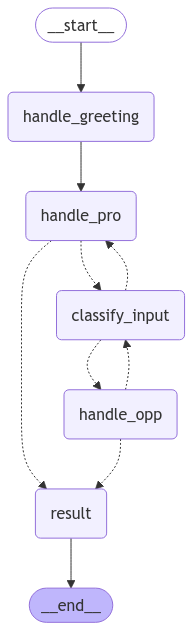

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

**Example of agent conversation (single question)**

In [ ]:
user_query = "Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?"
conversation = app.invoke({'count':0,'history':'Nothing','current_response':'', 'query':user_query})

<ipython-input-16-bd4b95989f56>:27: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  similar_chunks = retriever.get_relevant_documents(query)


**Conversation history**

In [ ]:
print(conversation['history'])

START

A:The individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges is Sam Bankman-Fried, the founder of the failed cryptocurrency exchange FTX, who is accused of committing fraud for personal gain through the misappropriation of customer funds.
A:The individual facing a criminal trial on fraud and conspiracy charges is Sam Bankman-Fried, founder of FTX, as he is accused by prosecutors of orchestrating a multi-billion-dollar fraud through the misappropriation of customer funds for personal gain, with evidence including testimonies from former associates and allegations of intentional deception.
A:A: The individual facing a criminal trial on fraud and conspiracy charges is Sam Bankman-Fried, founder of FTX, as he is accused by prosecutors of orchestrating a multi-billion-dollar fraud through the misappropriation of customer funds for personal gain, with evidence including testimonies from former associates and allegations of intent

**Result**

In [ ]:
print(conversation["results"])

Sam Bankman-Fried


**Definition of evaluation functions**

In [ ]:
def calculate_retrieval_metrics(predicted_evidence, golden_evidence):
    predicted_evidence = [item.replace(" ", "").replace("\n", "") for item in predicted_evidence]
    golden_evidence = [item.replace(" ", "").replace("\n", "") for item in golden_evidence]

    true_positives = 0
    false_positives = 0
    false_negatives = 0

    for golden_item in golden_evidence:
        found = any(golden_item in chunk for chunk in predicted_evidence)
        if found:
            true_positives += 1
        else:
            false_negatives += 1

    for predicted_item in predicted_evidence:
        if not any(predicted_item in golden_item for golden_item in golden_evidence):
            false_positives += 1

    precision = true_positives / (true_positives + false_positives) if true_positives + false_positives > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if true_positives + false_negatives > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return precision, recall, f1

def has_intersection(predicted, actual):
    predicted_words = set(predicted.lower().split())
    actual_words = set(actual.lower().split())
    return len(predicted_words.intersection(actual_words)) > 0

def calculate_metrics(pred_list, gold_list):
    tp = sum(1 for pred, gold in zip(pred_list, gold_list) if has_intersection(pred, gold))
    fp = sum(1 for pred, gold in zip(pred_list, gold_list) if not has_intersection(pred, gold))
    fn = len(gold_list) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

def evaluate(rag_chain, dataset_qa, samples=None):
    pred_list = []
    gold_list = []
    all_predicted_evidence = []
    all_golden_evidence = []

    if samples != None:
        dataset = dataset_qa["train"].select(range(samples))
    else:
        dataset = dataset_qa["train"]

    for i, example in enumerate(tqdm(dataset, desc="Evaluation", unit="")):
        query = example["query"]
        #print(query)
        ground_truth = example["answer"]
        evidence_golden_list = example["evidence_list"]

        try:
          result = rag_chain.invoke({'count':0,'history':'Nothing','current_response':'', 'query':query})
          retrieved_chunks = retriever.invoke(query)
        except Exception as e:
          print(f"[[[[{query}]]]]")
          print(f"Exception type: {type(e).__name__}")
          print(f"Exception message: {str(e)}")
        prediction = result["results"] if result else "Insufficient Information"

        pred_list.append(prediction)
        gold_list.append(ground_truth)


        # print query
        print(f'\nQuestion: {query}')
        # print ground truth
        print(f'Ground Truth: {ground_truth}')
        # print prediction evaluation
        print(f'Result: {prediction}\tCheck: {"Correct" if prediction == ground_truth else "Incorrect"}')

        if (i + 1) % 1 == 0:
            golden_evidence = []
            predicted_evidence = []

            for evidence in evidence_golden_list:
                golden_evidence.append(evidence["fact"])

            for evidence in retrieved_chunks:
                predicted_evidence.append(evidence.page_content)

            all_predicted_evidence.extend(predicted_evidence)
            all_golden_evidence.extend(golden_evidence)

            #print(f"Retrieved Evidence: {predicted_evidence}")
            #print(f"Golden Evidence: {golden_evidence}")

            precision, recall, f1 = calculate_retrieval_metrics(predicted_evidence, golden_evidence)
            print(f"Retrieval: \tPrecision:{precision:.2f}\tRecall: {recall:.2f}\tF1 Score: {f1:.2f}")

            overall_precision, overall_recall, overall_f1 = calculate_retrieval_metrics(all_predicted_evidence, all_golden_evidence)
            print(f"Overall Retrieval:\tPrecision:{overall_precision:.2f}\tRecall: {overall_recall:.2f}\tF1 Score: {overall_f1:.2f}")

            accuracy, _, _ = calculate_metrics(pred_list, gold_list)
            print(f"Overall Accuracy: {accuracy:.2f}\n")

        if samples != None and i >= samples:
            break

### Experiments

#### GPT-4o-mini + Collaborative Multi-Agent

In [ ]:
evaluate(app, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:18<30:25, 18.43s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [00:45<38:05, 23.32s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [01:03<33:42, 20.85s/]

...


Question: Which company, according to articles from TechCrunch and The Age, has not only invested billions to remain the default search engine on various devices but is also accused of manipulating search results for ad revenue and harming news publishers' revenues through anticompetitive practices?
Ground Truth: Google
Result: Google	Check: Correct
Retrieval: 	Precision:0.13	Recall: 1.00	F1 Score: 0.23
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.66



Evaluation:  99%|█████████▉| 99/100 [42:12<00:22, 22.03s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.67



Evaluation: 100%|██████████| 100/100 [42:32<00:00, 25.53s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Consistent	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.75	F1 Score: 0.15
Overall Accuracy: 0.66



#### GPT-4 + Collaborative Multi-Agent

`model_name` was changed to GPT-4 before running the experiment

In [ ]:
evaluate(app, dataset_qa, 100)

Evaluation:   1%|          | 1/100 [00:49<1:22:18, 49.89s/]


Question: Who is the individual associated with the cryptocurrency industry facing a criminal trial on fraud and conspiracy charges, as reported by both The Verge and TechCrunch, and is accused by prosecutors of committing fraud for personal gain?
Ground Truth: Sam Bankman-Fried
Result: Sam Bankman-Fried	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Accuracy: 1.00



Evaluation:   2%|▏         | 2/100 [01:51<1:32:53, 56.87s/]


Question: Which individual is implicated in both inflating the value of a Manhattan apartment to a figure not yet achieved in New York City's real estate history, according to 'Fortune', and is also accused of adjusting this apartment's valuation to compensate for a loss in another asset's worth, as reported by 'The Age'?
Ground Truth: Donald Trump
Result: Donald Trump	Check: Correct
Retrieval: 	Precision:0.09	Recall: 1.00	F1 Score: 0.17
Overall Retrieval:	Precision:0.07	Recall: 0.60	F1 Score: 0.12
Overall Accuracy: 1.00



Evaluation:   3%|▎         | 3/100 [02:43<1:28:12, 54.56s/]

...

Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.74



Evaluation:  99%|█████████▉| 99/100 [1:22:29<01:00, 60.03s/]


Question: Do the articles from Sporting News on 'Line Shopping in Sports Betting' and 'NBA Rookie of the Year Odds' both agree that Sportsbooks adjust their practices (profit from odds and lines, and tighten betting lines) based on certain conditions, or do they present different strategies used by Sportsbooks?
Ground Truth: Agree
Result: Agree	Check: Correct
Retrieval: 	Precision:0.05	Recall: 0.33	F1 Score: 0.08
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.75



Evaluation: 100%|██████████| 100/100 [1:24:05<00:00, 50.45s/]


Question: Has the approach of Sportsbooks in adjusting betting lines and odds, as reported by Sporting News after October 4, 2023, and before November 1, 2023, remained consistent?
Ground Truth: no
Result: Yes	Check: Incorrect
Retrieval: 	Precision:0.05	Recall: 0.50	F1 Score: 0.09
Overall Retrieval:	Precision:0.08	Recall: 0.74	F1 Score: 0.15
Overall Accuracy: 0.74

